In [1]:
%pip install torchsummary
%pip install split-folders

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import time
import numpy as np
import torch as tc
import matplotlib.pyplot as plt

In [3]:
tc.cuda.is_available()

True

In [4]:
os.cpu_count()

4

In [5]:
import splitfolders

splitfolders.ratio('/kaggle/input/black-gram-plant-leaf-disease/BPLD', output='BPLD', ratio=(0.8, 0.2))

Copying files: 1007 files [00:06, 155.32 files/s]


In [6]:
from torchvision import datasets, transforms

mean = tc.Tensor([0.485, 0.456, 0.406])
std = tc.Tensor([0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
        transforms.Resize(232),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
])

train_dataset = datasets.ImageFolder(root='/kaggle/working/BPLD/train', transform=train_transform)
test_dataset = datasets.ImageFolder(root='/kaggle/working/BPLD/val', transform=test_transform)

In [7]:
print("Number of training samples:", len(train_dataset))
print("Number of testing samples:", len(test_dataset))

Number of training samples: 804
Number of testing samples: 203


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=8, num_workers=4)

In [9]:
def imshow(img):
    img = img * std.unsqueeze(1).unsqueeze(2) + mean.unsqueeze(1).unsqueeze(2)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

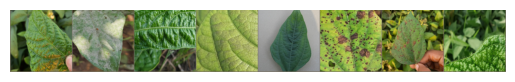

leaf crinckle, powdery mildew, leaf crinckle, healthy, healthy, anthracnose, anthracnose, leaf crinckle


In [10]:
from torchvision.utils import make_grid

images, labels = next(iter(train_loader))
imshow(make_grid(images))
print(', '.join(f'{train_loader.dataset.classes[labels[i]]}' for i in range(len(labels))))

In [11]:
from torchvision import models
from torchsummary import summary

model = models.resnet50(weights='ResNet50_Weights.IMAGENET1K_V2')
model = model.cuda()
summary(model, (3, 224, 224))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [12]:
for index, (name, param) in enumerate(model.named_parameters()):
    print(f"Index: {index}, Name: {name}, Requires Grad: {param.requires_grad}")

Index: 0, Name: conv1.weight, Requires Grad: True
Index: 1, Name: bn1.weight, Requires Grad: True
Index: 2, Name: bn1.bias, Requires Grad: True
Index: 3, Name: layer1.0.conv1.weight, Requires Grad: True
Index: 4, Name: layer1.0.bn1.weight, Requires Grad: True
Index: 5, Name: layer1.0.bn1.bias, Requires Grad: True
Index: 6, Name: layer1.0.conv2.weight, Requires Grad: True
Index: 7, Name: layer1.0.bn2.weight, Requires Grad: True
Index: 8, Name: layer1.0.bn2.bias, Requires Grad: True
Index: 9, Name: layer1.0.conv3.weight, Requires Grad: True
Index: 10, Name: layer1.0.bn3.weight, Requires Grad: True
Index: 11, Name: layer1.0.bn3.bias, Requires Grad: True
Index: 12, Name: layer1.0.downsample.0.weight, Requires Grad: True
Index: 13, Name: layer1.0.downsample.1.weight, Requires Grad: True
Index: 14, Name: layer1.0.downsample.1.bias, Requires Grad: True
Index: 15, Name: layer1.1.conv1.weight, Requires Grad: True
Index: 16, Name: layer1.1.bn1.weight, Requires Grad: True
Index: 17, Name: layer1.

In [13]:
for param in model.parameters():
    param.requires_grad = False

In [14]:
for index, (name, param) in enumerate(model.named_parameters()):
    print(f"Index: {index}, Name: {name}, Requires Grad: {param.requires_grad}")

Index: 0, Name: conv1.weight, Requires Grad: False
Index: 1, Name: bn1.weight, Requires Grad: False
Index: 2, Name: bn1.bias, Requires Grad: False
Index: 3, Name: layer1.0.conv1.weight, Requires Grad: False
Index: 4, Name: layer1.0.bn1.weight, Requires Grad: False
Index: 5, Name: layer1.0.bn1.bias, Requires Grad: False
Index: 6, Name: layer1.0.conv2.weight, Requires Grad: False
Index: 7, Name: layer1.0.bn2.weight, Requires Grad: False
Index: 8, Name: layer1.0.bn2.bias, Requires Grad: False
Index: 9, Name: layer1.0.conv3.weight, Requires Grad: False
Index: 10, Name: layer1.0.bn3.weight, Requires Grad: False
Index: 11, Name: layer1.0.bn3.bias, Requires Grad: False
Index: 12, Name: layer1.0.downsample.0.weight, Requires Grad: False
Index: 13, Name: layer1.0.downsample.1.weight, Requires Grad: False
Index: 14, Name: layer1.0.downsample.1.bias, Requires Grad: False
Index: 15, Name: layer1.1.conv1.weight, Requires Grad: False
Index: 16, Name: layer1.1.bn1.weight, Requires Grad: False
Index: 

In [15]:
import torch.nn as nn
import torch.nn.init as init

model.fc = nn.Linear(model.fc.in_features, 5)
init.xavier_normal_(model.fc.weight)
model = model.cuda()
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [16]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.RAdam(model.fc.parameters(), lr=9e-3, weight_decay=3e-6, decoupled_weight_decay=True, foreach=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=28)

In [17]:
num_epochs = 28

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    epoch_train_loss = 0
    epoch_val_loss = 0
    epoch_train_corrects = 0
    epoch_val_corrects = 0

    model.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.cuda(), targets.cuda()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        preds = tc.argmax(outputs, dim=1)
        
        loss = criterion(outputs, targets)
        epoch_train_loss += loss.item() * inputs.size(0)
        epoch_train_corrects += tc.sum(preds == targets.data).float()

        loss.backward()
        optimizer.step()

    scheduler.step()

    epoch_train_loss /= len(train_dataset)
    epoch_train_accuracy = epoch_train_corrects / len(train_dataset)
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy.cpu())

    model.eval()
    with tc.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.cuda(), targets.cuda()
            
            val_outputs = model(inputs)
            
            val_preds = tc.argmax(val_outputs, dim=1)
            
            val_loss = criterion(val_outputs, targets)
            epoch_val_loss += val_loss.item() * inputs.size(0)
            epoch_val_corrects += tc.sum(val_preds == targets.data).float()

    epoch_val_loss /= len(test_dataset)
    epoch_val_accuracy = epoch_val_corrects / len(test_dataset)
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy.cpu())

    print("Epoch {}/{}: Train Loss = {:.4f}, Val Loss = {:.4f}, Train Acc = {:.4f}, Val Acc = {:.4f}".format(
        epoch + 1, num_epochs, train_losses[-1], val_losses[-1], train_accuracies[-1], val_accuracies[-1]))

end_time = time.time()
training_time = end_time - start_time

print("Training time: {:.2f}s".format(training_time))

Epoch 1/28: Train Loss = 1.1819, Val Loss = 0.8655, Train Acc = 0.5945, Val Acc = 0.7980
Epoch 2/28: Train Loss = 0.5495, Val Loss = 0.5709, Train Acc = 0.8607, Val Acc = 0.8621
Epoch 3/28: Train Loss = 0.4394, Val Loss = 0.3698, Train Acc = 0.8483, Val Acc = 0.9163
Epoch 4/28: Train Loss = 0.3793, Val Loss = 0.3629, Train Acc = 0.8731, Val Acc = 0.9064
Epoch 5/28: Train Loss = 0.3140, Val Loss = 0.2711, Train Acc = 0.8980, Val Acc = 0.9458
Epoch 6/28: Train Loss = 0.2725, Val Loss = 0.2326, Train Acc = 0.9104, Val Acc = 0.9458
Epoch 7/28: Train Loss = 0.2702, Val Loss = 0.2265, Train Acc = 0.9080, Val Acc = 0.9409
Epoch 8/28: Train Loss = 0.2549, Val Loss = 0.2931, Train Acc = 0.9266, Val Acc = 0.9261
Epoch 9/28: Train Loss = 0.2171, Val Loss = 0.2474, Train Acc = 0.9241, Val Acc = 0.9163
Epoch 10/28: Train Loss = 0.1929, Val Loss = 0.2237, Train Acc = 0.9378, Val Acc = 0.9458
Epoch 11/28: Train Loss = 0.2584, Val Loss = 0.2564, Train Acc = 0.9129, Val Acc = 0.9261
Epoch 12/28: Train 

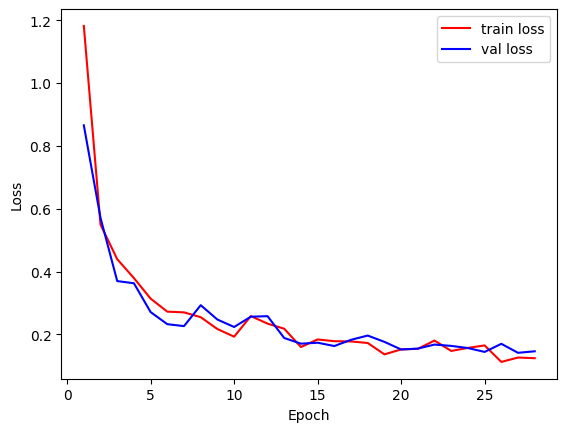

In [18]:
plt.plot(range(1, num_epochs + 1), train_losses, color="red", label="train loss")
plt.plot(range(1, num_epochs + 1), val_losses, color="blue", label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

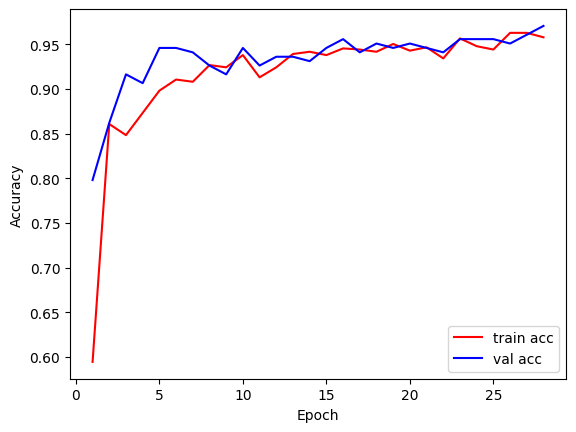

In [19]:
plt.plot(range(1, num_epochs + 1), train_accuracies, color="red", label="train acc")
plt.plot(range(1, num_epochs + 1), val_accuracies, color="blue", label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [20]:
y_test = []
y_pred = []

model.eval()

with tc.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.cuda()
        outputs = model(inputs)
        preds = tc.argmax(outputs, dim=1)
        y_test.append(targets)
        y_pred.append(preds)

y_test = tc.cat(y_test).cpu()
y_pred = tc.cat(y_pred).cpu()

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy score: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision score: {:.4f}".format(precision_score(y_test, y_pred, average='weighted')))
print("Recall score: {:.4f}".format(recall_score(y_test, y_pred, average='weighted')))
print("F1 score: {:.4f}".format(f1_score(y_test, y_pred, average='weighted')))

Accuracy score: 0.9704
Precision score: 0.9713
Recall score: 0.9704
F1 score: 0.9704


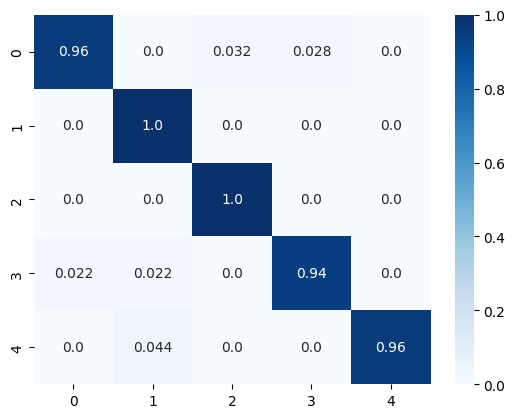

In [22]:
import seaborn as sb
from sklearn.metrics import confusion_matrix

cfm = confusion_matrix(y_test, y_pred)

sb.heatmap(cfm / np.sum(cfm, axis=1), annot=True, fmt=".2", cmap="Blues")
plt.show()

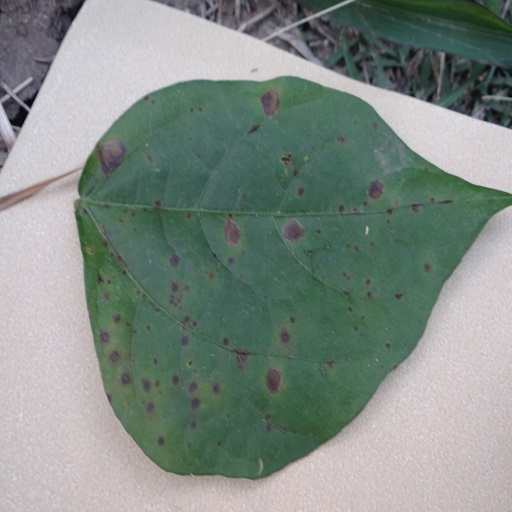

In [23]:
from PIL import Image

image = Image.open('/kaggle/input/black-gram-plant-leaf-disease/BPLD/anthracnose/100a.jpg')
image

In [24]:
image = test_transform(image).unsqueeze(0)
image = image.cuda()

model.eval()

with tc.no_grad():
    output = model(image)
    prediction = tc.argmax(output, dim=1)
    
print('The predicted plant leaf disease is', test_loader.dataset.classes[prediction])

The predicted plant leaf disease is anthracnose


In [25]:
tc.save(model, 'model.pth')